Lanagchain Core Concepts

In [6]:
def m_g(state):
    """
    the function takes a dictionary as input and returns a greeting message based on the "name" key in the dictionary.
    """
    name = state["name"]
    return {"greeting": f"hello,{name}!"}

c_s = {"name": "John"}
u = m_g(c_s)
print(u)

{'greeting': 'hello,John!'}


Initial State
-------------
value = 5

      │
      ▼
Double Node
-------------
5 × 2 = 10

State
-------------
value = 10

      │
      ▼
Increment Node
-------------
10 + 10 = 20

State
-------------
value = 20

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
#state type definition
class State(TypedDict):
    value: int

def d(state: State):
    return {"value": state["value"] * 2}

def e(state: State):
    return {"value": state["value"] + 10}

builder = StateGraph(State)
#node addition
builder.add_node("Double", d)
builder.add_node("Increment", e)
#edge addition
builder.add_edge(START, "Double")
builder.add_edge("Double", "Increment")
builder.add_edge("Increment", END)
#graph compilation and invocation
graph = builder.compile()

result = graph.invoke({"value": 5})
print(result)

{'value': 20}


Application Based Scenario on Langgraph 

Input
│
▼
raw_text
│
▼
CleanText
│
├── Removes punctuation
├── Converts to lowercase
│
▼
cleaned_text
│
▼
CountWords
│
├── Splits into words
├── Counts total words (18)
│
▼
word_count
│
▼
SummarizeText
│
├── Takes first 10 words
├── Joins them into one sentence
├── Adds "..."
│
▼
summary
│
▼
END
│
▼
Final State

In [4]:
import re
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class GraphState(TypedDict):
    raw_text: str
    cleaned_text: str
    word_count: int
    summary: str
def clean_text(state: GraphState):
    cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', '',state["raw_text"].strip()).lower()
    return {"cleaned_text": cleaned_text}
def count_words(state: GraphState):
    word_count = len(state["cleaned_text"].split())
    return {"word_count": word_count}
def summarize_text(state: GraphState):
    words = state["cleaned_text"].split()
    summary = ' '.join(words[:10]) + '...' if len(words) > 10 else state["cleaned_text"]
    return {"summary": summary}

builder = StateGraph(GraphState)
builder.add_node("CleanText", clean_text)
builder.add_node("CountWords", count_words)
builder.add_node("SummarizeText", summarize_text)

builder.add_edge(START, "CleanText")
builder.add_edge("CleanText", "CountWords")
builder.add_edge("CountWords", "SummarizeText")
builder.add_edge("SummarizeText", END)

runnable = builder.compile()
result = runnable.invoke({"raw_text": "This is a sample text for testing the text processing graph. It should clean, count words, and summarize."})
print(result["word_count"]) 
print(result["summary"]) 
     


18
this is a sample text for testing the text processing...


State Management Deep Dive 

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class bl(TypedDict):
    steps: list
def step_one(state: bl) -> dict:
    c = state["steps"]
    n_c = c + ["step_one"]
    print(f"Step one executed. Current steps: {n_c}")
    return {"steps": n_c}
def step_two(state: bl) -> dict:
    c = state["steps"]
    n_c = c + ["step_two"]
    print(f"Step two executed. Current steps: {n_c}")
    return {"steps": n_c}
b = StateGraph(bl)
b.add_node("Step_One", step_one) 
b.add_node("Step_Two", step_two)

b.add_edge(START, "Step_One")
b.add_edge("Step_One", "Step_Two")    

graph = b.compile()
result = graph.invoke({"steps": []})
print(result["steps"])




Step one executed. Current steps: ['step_one']
Step two executed. Current steps: ['step_one', 'step_two']
['step_one', 'step_two']


Based on the Above program Which Adding the memory so memory so we can reduces

In [5]:
from typing import TypedDict,Annotated
from operator import add 
from langgraph.graph import StateGraph, START, END

class bl(TypedDict):
    steps : Annotated[list,add] 
def step_one(state: bl) -> dict:
    c = state["steps"]
    n_c = c + ["step_one"]
    print(f"Step one executed. Current steps: {n_c}")
    return {"steps": n_c}
def step_two(state: bl) -> dict:
    c = state["steps"]
    n_c = c + ["step_two"]
    print(f"Step two executed. Current steps: {n_c}")
    return {"steps": n_c}
b = StateGraph(bl)
b.add_node("Step_One", step_one) 
b.add_node("Step_Two", step_two)

b.add_edge(START, "Step_One")
b.add_edge("Step_One", "Step_Two")    

graph = b.compile()
result = graph.invoke({"steps": []})
print(result["steps"])


Step one executed. Current steps: ['step_one']
Step two executed. Current steps: ['step_one', 'step_two']
['step_one', 'step_one', 'step_two']


Add Message Deduplication and Memory Management and stored by id 

In [6]:
# add_messages reducer in action
# Messages accumulate across nodes - no manual list management needed.

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage


# Option A: define the state yourself
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]   # add_messages is the reducer
    turn: int                                 # regular field (no reducer)


def node_human_input(state: ChatState) -> dict:
    # Simulates adding a human message.
    new_msg = HumanMessage(content="What is the capital of France?")
    print(f"  [human_input] appending: {new_msg.content!r}")
    return {
        "messages": [new_msg],   # just pass the new message(s)
        "turn": state["turn"] + 1,
    }


def node_ai_reply(state: ChatState) -> dict:
    # Simulates an AI response (no real LLM - hard-coded for the demo).
    new_msg = AIMessage(content="The capital of France is Paris.")
    print(f"  [ai_reply] appending: {new_msg.content!r}")
    return {"messages": [new_msg]}   # add_messages appends this


builder = StateGraph(ChatState)
builder.add_node("human_input", node_human_input)
builder.add_node("ai_reply",    node_ai_reply)
builder.add_edge(START,         "human_input")
builder.add_edge("human_input", "ai_reply")
builder.add_edge("ai_reply",    END)
graph = builder.compile()

result = graph.invoke({"messages": [], "turn": 0})
print("\nFinal turn count:", result["turn"])
print("Final message list:")
for msg in result["messages"]:
    role = "Human" if isinstance(msg, HumanMessage) else "AI"
    print(f"  [{role}] {msg.content}")

  [human_input] appending: 'What is the capital of France?'
  [ai_reply] appending: 'The capital of France is Paris.'

Final turn count: 1
Final message list:
  [Human] What is the capital of France?
  [AI] The capital of France is Paris.


Graphical Flow Sequential Flow

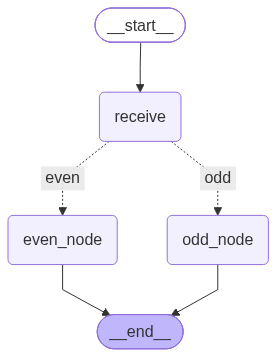

In [13]:
from IPython.display import display, Image
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]   # add_messages is the reducer
    turn: int 
graph = builder.compile()
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)



Conditional Edges

8
  Received number: 8
  [even_node] 8 is EVEN
{'number': 8, 'result': '8 is EVEN'}

7
  Received number: 7
  [odd_node] 7 is ODD
{'number': 7, 'result': '7 is ODD'}


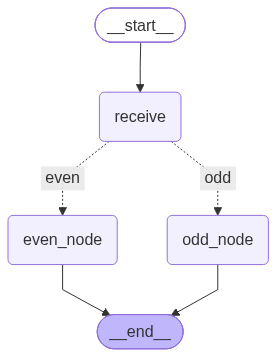

In [12]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END


# --- State ---
class NumberState(TypedDict):
    number: int
    result: str   # will be filled by the branch node


# --- Step 1: entry node - just logs and passes the number through ---
def receive_number(state: NumberState) -> dict:
    # Entry node - just prints and passes the number through unchanged.
    print(f"  Received number: {state['number']}")
    return {}   # no change to state


# Returns a Literal so type checkers can verify we handle all cases.
def route_even_or_odd(state: NumberState) -> Literal["even", "odd"]:
    # Return 'even' or 'odd' based on the number in state.
    if state["number"] % 2 == 0:
        return "even"
    else:
        return "odd"

def even_node(state: NumberState) -> dict:
    msg = f"{state['number']} is EVEN"
    print(f"  [even_node] {msg}")
    return {"result": msg}

def odd_node(state: NumberState) -> dict:
    msg = f"{state['number']} is ODD"
    print(f"  [odd_node] {msg}")
    return {"result": msg}


builder = StateGraph(NumberState)

builder.add_node("receive",   receive_number)
builder.add_node("even_node", even_node)
builder.add_node("odd_node",  odd_node)

builder.add_edge(START, "receive")

# The conditional edge: after "receive", call route_even_or_odd to pick next node
builder.add_conditional_edges(
    "receive",           # source node
    route_even_or_odd,   # routing function
    {
        "even": "even_node",   # if routing fn returns "even", go to even_node
        "odd":  "odd_node",    # if routing fn returns "odd",  go to odd_node
    }
)

builder.add_edge("even_node", END)
builder.add_edge("odd_node",  END)

graph = builder.compile()
print("8")
print(graph.invoke({"number": 8,  "result": ""}))

print()
print("7")
print(graph.invoke({"number": 7, "result": ""}))

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

Dynamic Routing

Task: 'math'
  [math_worker] 3 * 7 + 2 = 23
  Result: 23

Task: 'text'
  [text_worker] 'hello world' -> 'HELLO WORLD'
  Result: HELLO WORLD

Task: 'unknown'
  [fallback] Unknown task type: 'unknown'
  Result: Unknown task type: 'unknown'



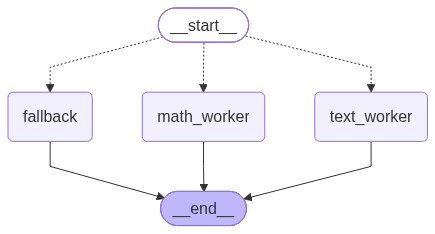

In [15]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END


# --- State ---
class TaskState(TypedDict):
    task_type: str   # "math", "text", or "unknown"
    input_data: str
    output: str


# --- Routing function - reads state at runtime ---
def dispatch(state: TaskState) -> Literal["math_worker", "text_worker", "fallback"]:
    # Choose the right worker based on the task_type stored in state.
    task = state["task_type"].lower().strip()
    if task == "math":
        return "math_worker"
    elif task == "text":
        return "text_worker"
    else:
        return "fallback"


# --- Worker nodes ---
def math_worker(state: TaskState) -> dict:
    # Pretend to evaluate a simple expression
    try:
        result = str(eval(state["input_data"]))
    except Exception:
        result = "math error"
    print(f"  [math_worker] {state['input_data']} = {result}")
    return {"output": result}
def text_worker(state: TaskState) -> dict:
    result = state["input_data"].upper()
    print(f"  [text_worker] '{state['input_data']}' -> '{result}'")
    return {"output": result}

def fallback(state: TaskState) -> dict:
    result = f"Unknown task type: '{state['task_type']}'"
    print(f"  [fallback] {result}")
    return {"output": result}


# --- Build the graph ---
builder = StateGraph(TaskState)

builder.add_node("math_worker", math_worker)
builder.add_node("text_worker", text_worker)
builder.add_node("fallback",    fallback)

# The START node goes straight to the conditional dispatcher
builder.add_conditional_edges(
    START,      # source is START itself - first thing the graph does is route
    dispatch,
    {
        "math_worker": "math_worker",
        "text_worker": "text_worker",
        "fallback":    "fallback",
    }
)

builder.add_edge("math_worker", END)
builder.add_edge("text_worker", END)
builder.add_edge("fallback",    END)

graph = builder.compile()
# --- Run three different task types ---
tasks = [
    {"task_type": "math",    "input_data": "3 * 7 + 2",    "output": ""},
    {"task_type": "text",    "input_data": "hello world",  "output": ""},
    {"task_type": "unknown", "input_data": "do something", "output": ""},
]

for task in tasks:
    print(f"Task: {task['task_type']!r}")
    out = graph.invoke(task)
    print(f"  Result: {out['output']}")
    print()
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)